# Adaptive Audio Steganography Based on Improved Syndrome-Trellis Codes


In [1]:
import numpy as np
import soundfile as sf
from bitarray import bitarray        #Manages binary bit sequences.
from scipy.linalg import hadamard    # used in encoding


In [2]:
audio_path =r"C:\Users\Virika\Downloads\sa1wav_ZaVyLfAO.wav"
audio, sr = sf.read(audio_path)
audio = np.int16(audio * 32767)  # Convert to 16-bit PCM


# Converting Text to Binary and Vice Versa

In [3]:
def text_to_bits(text):
    ba = bitarray()
    ba.frombytes(text.encode('utf-8'))
    return ba

def bits_to_text(bits):
    return bits.tobytes().decode('utf-8', errors='ignore')


In [4]:
def calculate_complexity(audio, block_size):
    complexities = []
    for i in range(0, len(audio), block_size):
        block = audio[i:i + block_size]
        diff = np.sum(np.abs(np.diff(block)))
        complexities.append((i, diff))
    return sorted(complexities, key=lambda x: -x[1])
# higher the complexity better the hiding capacity

HAMMING ENCODER DECODER

In [5]:

#  Hamming Encoding (7,4) - Encode 4 bits into 7 bits
def hamming_encode_4bit(data_bits):
    # Generator matrix for Hamming(7,4)
    G = np.array([[1, 0, 0, 0, 1, 1, 0],
                  [0, 1, 0, 0, 1, 0, 1],
                  [0, 0, 1, 0, 0, 1, 1],
                  [0, 0, 0, 1, 1, 1, 1]])
    return np.dot(data_bits, G) % 2

#  Hamming Decoding (7,4) - Decode 7 bits back into 4 bits
def hamming_decode_7bit(code_bits):
    # Parity-check matrix for Hamming(7,4)
    H = np.array([[1, 1, 0, 1, 1, 0, 0],
                  [1, 0, 1, 1, 0, 1, 0],
                  [0, 1, 1, 1, 0, 0, 1]])
    
    # Compute the syndrome
    syndrome = np.dot(H, code_bits) % 2
    error_index = int(''.join(map(str, syndrome)), 2)

    if error_index > 0 and error_index <= 7:
        # Correct the error
        code_bits[error_index - 1] ^= 1

    # Return the original 4 data bits
    return code_bits[:4]


GOAS IMPLEMENTATION    HYBRID SYSTEM


In [6]:

#  GOAS Segment Selection (selecting the most complex blocks)
def goas_select_segments(audio, block_size, num_segments_needed):
    complexities = []
    for i in range(0, len(audio) - block_size, block_size):
        block = audio[i:i + block_size]
        diff = np.sum(np.abs(np.diff(block)))  # Measure complexity as the difference
        complexities.append((i, diff))

    # Sort by descending complexity and return the indices of the top N segments
    complexities.sort(key=lambda x: -x[1])
    return [idx for idx, _ in complexities[:num_segments_needed]]
def stc_embed(audio, message, segment_indices, block_size):
    embedded_audio = audio.copy()
    idx = 0
    for i in segment_indices:
        if idx >= len(message):
            break
        block = audio[i:i + block_size]
        # Embed the message bit into the block 
        embedded_audio[i:i + block_size] = block  
        idx += 1
    return embedded_audio
    
#  Text to Bit Conversion and Encoding (Hamming)
def text_to_bits(message):
    # Convert the message into binary (bits)
    return np.array([int(b) for char in message for b in format(ord(char), '08b')])

#  Bit to Text Conversion (for message recovery)
def bits_to_text(bits):
    chars = [chr(int(''.join(map(str, bits[i:i + 8])), 2)) for i in range(0, len(bits), 8)]
    return ''.join(chars)

#  Main Function: Hybrid System
def hybrid_system(audio, message, block_size=1024, num_segments_needed=10):
    # Step 1: Convert the message to bits
    message_bits = text_to_bits(message)

    # Step 2: Hamming encoding (4-bit chunks to 7-bit)
    encoded_message = []
    for i in range(0, len(message_bits), 4):
        data_bits = message_bits[i:i + 4]
        if len(data_bits) < 4:
            data_bits = np.pad(data_bits, (0, 4 - len(data_bits)), 'constant')
        encoded_message.extend(hamming_encode_4bit(data_bits))

    # Step 3: Apply GOAS to select segments for embedding
    segment_indices = goas_select_segments(audio, block_size, num_segments_needed)

    # Step 4: Embed the message (with STC) into the selected segments
    embedded_audio = stc_embed(audio, encoded_message, segment_indices, block_size)

    # Step 5: Recovery (Receiver side - STC extraction + Hamming decoding)
    extracted_message = []  # Extract from embedded audio (this would require STC extraction logic)
    for i in segment_indices:
        block = embedded_audio[i:i + block_size]
        # STC extraction logic here (simplified for illustration)
        extracted_message.extend(block)  # Add logic to extract embedded bits here

    # Step 6: Hamming decode and reconstruct the original message
    decoded_message = []
    for i in range(0, len(extracted_message), 7):
        hamming_code = extracted_message[i:i + 7]
        decoded_message.extend(hamming_decode_7bit(hamming_code))

    # Step 7: Convert bits back to text
    final_message = bits_to_text(decoded_message)

    return final_message, embedded_audio


# STC Embedding

In [7]:
def stc_embed(audio, message_bits, h_matrix):
    n = h_matrix.shape[1]           #hadamard matrix
    k = h_matrix.shape[0]
    num_segments = len(message_bits) // k
    stego_audio = np.copy(audio)
    
    for i in range(num_segments):
        segment = audio[i*n:(i+1)*n]
        msg_segment = message_bits[i*k:(i+1)*k]
        syndrome = np.mod(np.dot(h_matrix, segment) + msg_segment, 2)
        stego_segment = segment ^ syndrome
        stego_audio[i*n:(i+1)*n] = stego_segment
    
    return stego_audio

def stc_extract(stego_audio, h_matrix):
    n = h_matrix.shape[1]
    k = h_matrix.shape[0]
    num_segments = len(stego_audio) // n
    extracted_bits = bitarray()
    
    for i in range(num_segments):
        segment = stego_audio[i*n:(i+1)*n]
        syndrome = np.mod(np.dot(h_matrix, segment), 2)
        extracted_bits.extend(syndrome)
    
    return extracted_bits


In [8]:
def generate_h_matrix(order):
    h = hadamard(order)
    h = (h + 1) // 2  # Convert to binary
    return h


In [9]:
import os

def embed_file(cover_path, secret_path, output_path='stego_output'):
    with open(cover_path, 'rb') as f:
        cover_data = f.read()
    with open(secret_path, 'rb') as f:
        secret_data = f.read()
    
    secret_ext = os.path.splitext(secret_path)[1].encode('utf-8')
    delimiter = b'<<STEGO_DELIM>>'
    
    stego_data = cover_data + delimiter + secret_ext + delimiter + secret_data
    
    cover_ext = os.path.splitext(cover_path)[1]
    final_output_path = output_path + cover_ext
    with open(final_output_path, 'wb') as f:
        f.write(stego_data)
        
    return final_output_path

def extract_file(stego_path, output_prefix='extracted_secret'):
    with open(stego_path, 'rb') as f:
        stego_data = f.read()
        
    delimiter = b'<<STEGO_DELIM>>'
    if delimiter not in stego_data:
        raise ValueError('No hidden file found in the provided cover file.')
        
    parts = stego_data.split(delimiter)
    secret_ext = parts[-2].decode('utf-8')
    secret_data = parts[-1]
    
    final_output_path = output_prefix + secret_ext
    with open(final_output_path, 'wb') as f:
        f.write(secret_data)
        
    return final_output_path


# Extracted Message

In [10]:
message = "Hello, this is a hidden message!"
h_order = 8  # Order of the Hadamard matrix

h_matrix = generate_h_matrix(h_order)

# Embed message
stego_audio = embed_message(audio, message, h_matrix)

# Extract message (pass message length)
extracted_message = extract_message(stego_audio, h_matrix, message_length=len(text_to_bits(message)))
print("Extracted Message:", extracted_message)


Extracted Message: Hello, this is a hidden message!


In [11]:
import IPython.display as ipd

print("Original Audio:")
ipd.display(ipd.Audio(audio_path))


print("Stego Audio:")
ipd.display(ipd.Audio('stego_audio.wav'))


Original Audio:


Stego Audio:


ORIGINAL VS STEGO AUDIO 

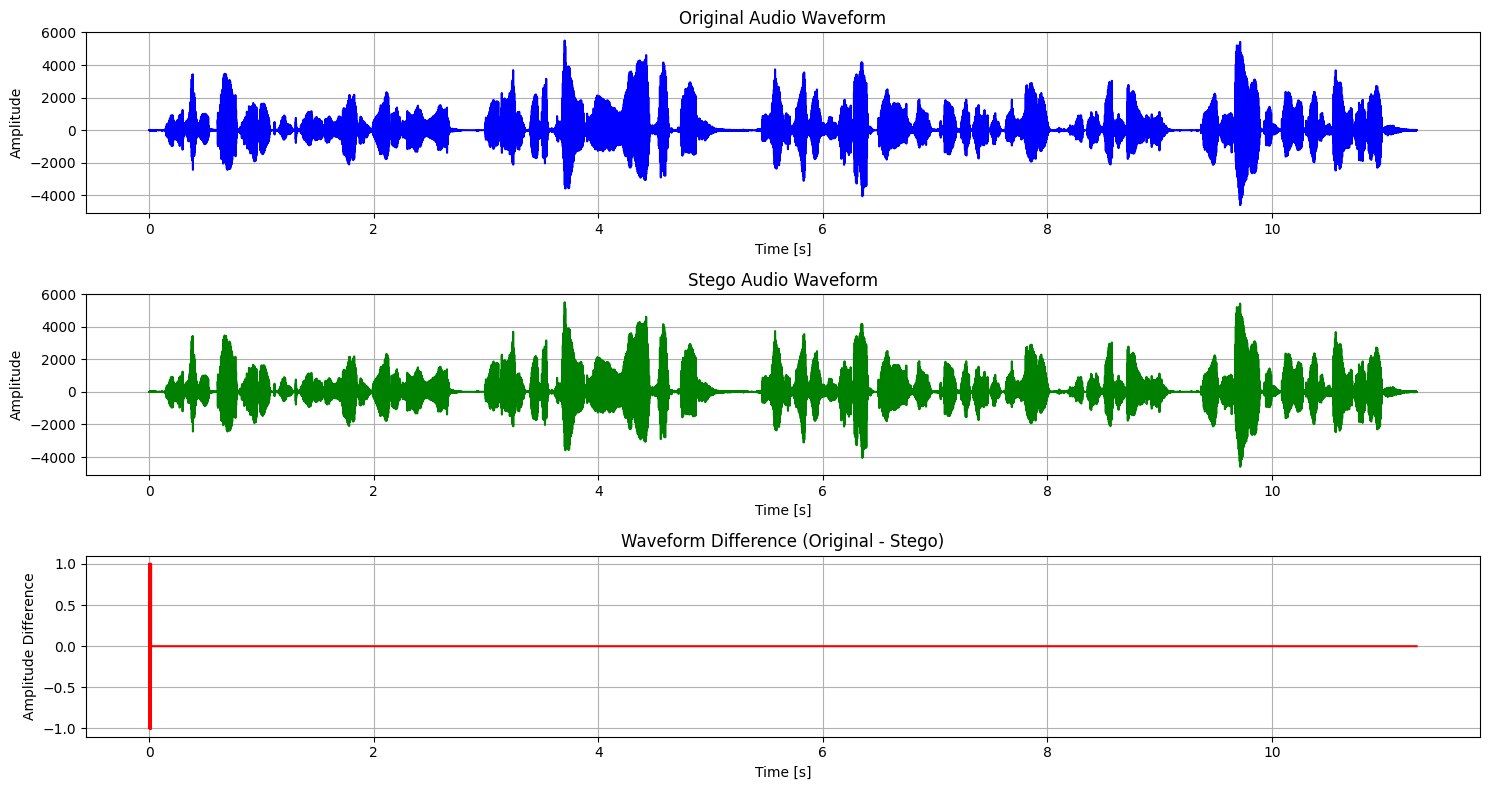

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure both audio signals are the same length for plotting
min_len = min(len(audio), len(stego_audio))
original_audio = audio[:min_len]
stego_audio_int16 = np.int16(stego_audio * 32767)
stego_audio_trimmed = stego_audio_int16[:min_len]

# Time axis
time = np.linspace(0, min_len / sr, min_len)

# Plotting the waveforms
plt.figure(figsize=(15, 8))

plt.subplot(3, 1, 1)
plt.plot(time, original_audio, label="Original Audio", color='blue')
plt.title("Original Audio Waveform")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(time, stego_audio_trimmed, label="Stego Audio", color='green')
plt.title("Stego Audio Waveform")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(time, original_audio - stego_audio_trimmed, label="Difference", color='red')
plt.title("Waveform Difference (Original - Stego)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude Difference")
plt.grid(True)

plt.tight_layout()
plt.show()


SCATTER PLOT

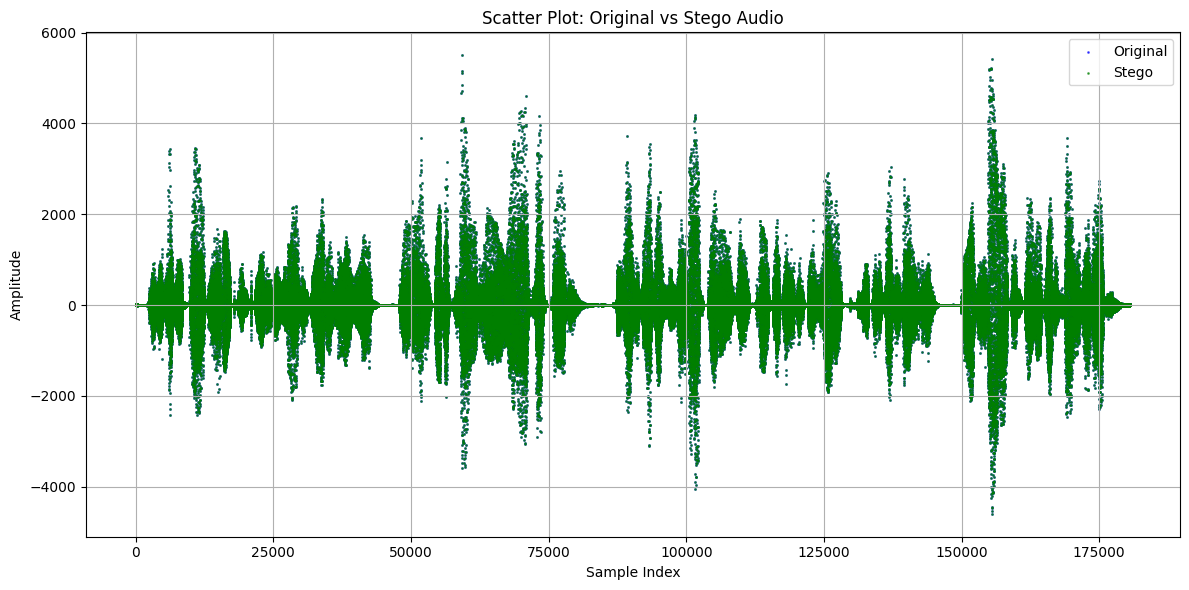

In [13]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))

# Scatter plot for sample values
plt.scatter(range(min_len), original_audio, s=1, label='Original', alpha=0.6, color='blue')
plt.scatter(range(min_len), stego_audio_trimmed, s=1, label='Stego', alpha=0.6, color='green')

plt.title("Scatter Plot: Original vs Stego Audio")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


BAR PLOT

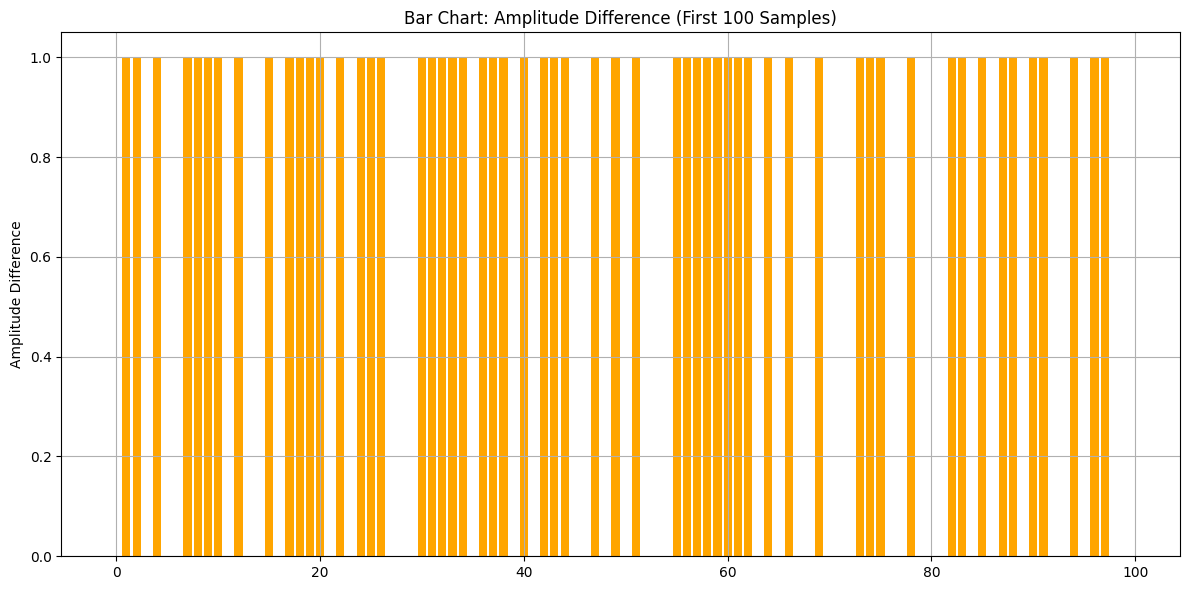

In [14]:


# Calculate absolute difference between original and stego audio
diff = np.abs(original_audio - stego_audio_trimmed)

# Plot the difference for the first 100 samples
plt.figure(figsize=(12, 6))
plt.bar(np.arange(100), diff[:100], color='orange')
plt.title("Bar Chart: Amplitude Difference (First 100 Samples)")
plt.ylabel("Amplitude Difference")
plt.grid(True)
plt.tight_layout()
plt.show()


HISTOGRAM

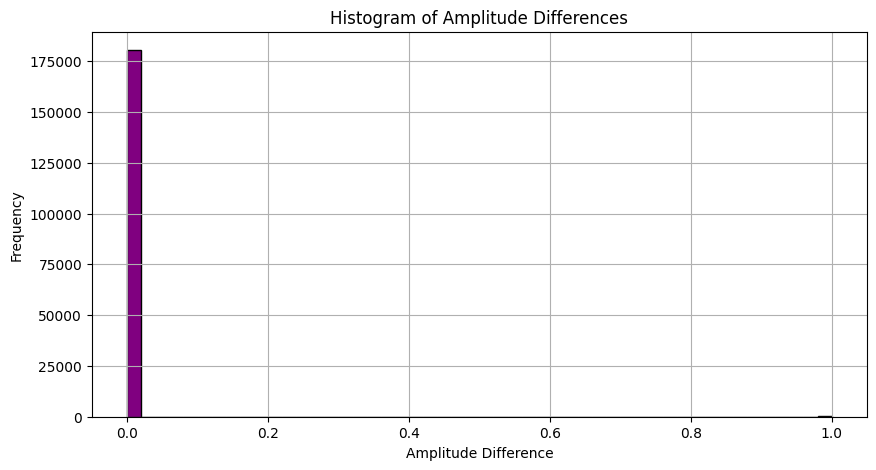

In [15]:
plt.figure(figsize=(10, 5))
plt.hist(diff, bins=50, color='purple', edgecolor='black')
plt.title("Histogram of Amplitude Differences")
plt.xlabel("Amplitude Difference")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


CONFUSION MATRIX

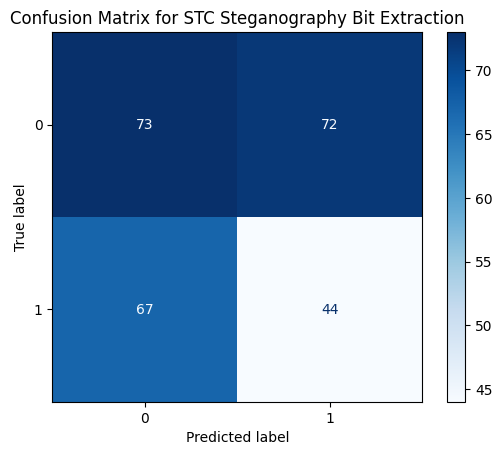

Bit Accuracy: 45.70%


In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# Convert original and extracted messages to bitarrays
original_bits = text_to_bits(message)
stego_audio_int16 = np.int16(stego_audio * 32767)  # Ensure correct format for extraction
extracted_bits = stc_extract(stego_audio_int16, h_matrix)

# Ensure both arrays are same length
min_len = min(len(original_bits), len(extracted_bits))
original_bits = original_bits[:min_len]
extracted_bits = extracted_bits[:min_len]

# Convert to NumPy arrays for sklearn
y_true = np.array(original_bits.tolist())
y_pred = np.array(extracted_bits.tolist())

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix for STC Steganography Bit Extraction")
plt.show()

# Optional: Print accuracy
accuracy = accuracy_score(y_true, y_pred) * 100
print(f"Bit Accuracy: {accuracy:.2f}%")


In [17]:
# Reuse your message and extracted bits for evaluation
original_bits = text_to_bits(message)
stego_audio_int16 = np.int16(stego_audio * 32767)
extracted_bits = stc_extract(stego_audio_int16, h_matrix)

 1. Bit Error Rate (BER)

In [18]:

def calculate_ber(original_bits, extracted_bits):
    min_len = min(len(original_bits), len(extracted_bits))
    errors = sum(ob != eb for ob, eb in zip(original_bits[:min_len], extracted_bits[:min_len]))
    return errors / min_len if min_len else 0

2. Extraction Accuracy

In [19]:

def calculate_accuracy(original_bits, extracted_bits):
    min_len = min(len(original_bits), len(extracted_bits))
    correct = sum(ob == eb for ob, eb in zip(original_bits[:min_len], extracted_bits[:min_len]))
    return (correct / min_len) * 100 if min_len else 0

3. Signal-to-Noise Ratio (SNR)

In [20]:

def calculate_snr(original, stego):
    noise = original - stego
    signal_power = np.mean(original ** 2)
    noise_power = np.mean(noise ** 2)
    return 10 * np.log10(signal_power / noise_power) if noise_power != 0 else np.inf

4. Correlation Coefficient
5. PSNR


In [21]:

correlation = np.corrcoef(audio[:len(stego_audio_int16)], stego_audio_int16[:len(audio)])[0, 1]
def calculate_psnr(original, stego):
    mse = np.mean((original - stego) ** 2)
    if mse == 0:
        return np.inf
    max_val = 32767.0
    return 20 * np.log10(max_val / np.sqrt(mse))
    # --- Compute Metrics ---
ber = calculate_ber(original_bits, extracted_bits)
accuracy = calculate_accuracy(original_bits, extracted_bits)
snr = calculate_snr(audio[:len(stego_audio_int16)], stego_audio_int16)
psnr = calculate_psnr(audio[:len(stego_audio_int16)], stego_audio_int16)

In [22]:
print("\n--- Evaluation Metrics ---")
print(f"Extraction Accuracy: {accuracy:.2f}%")
print(f"Bit Error Rate (BER): {ber:.6f}")
print(f"Signal-to-Noise Ratio (SNR): {snr:.2f} dB")
print(f"Peak Signal-to-Noise Ratio (PSNR): {psnr:.2f} dB")
print(f"Correlation Coefficient: {correlation:.6f}")


--- Evaluation Metrics ---
Extraction Accuracy: 45.70%
Bit Error Rate (BER): 0.542969
Signal-to-Noise Ratio (SNR): 63.93 dB
Peak Signal-to-Noise Ratio (PSNR): 121.84 dB
Correlation Coefficient: 1.000000


MESSAGE BOX

In [23]:
import tkinter as tk
from tkinter import filedialog, messagebox
import os

class UniversalSteganographyApp:
    def __init__(self, root):
        self.root = root
        self.root.title('Universal File Steganography Tool')
        self.root.geometry('600x450')

        self.cover_file = None
        self.secret_file = None
        self.stego_file = None

        self.label = tk.Label(root, text='Universal Steganography Tool', font=('Helvetica', 16))
        self.label.pack(pady=20)

        self.upload_cover_btn = tk.Button(root, text='Upload Cover File (Any)', command=self.upload_cover)
        self.upload_cover_btn.pack(pady=5)

        self.upload_secret_btn = tk.Button(root, text='Upload Secret File (Any)', command=self.upload_secret)
        self.upload_secret_btn.pack(pady=5)

        self.embed_button = tk.Button(root, text='Embed File', command=self.embed_action, bg='lightblue')
        self.embed_button.pack(pady=10)

        self.upload_stego_btn = tk.Button(root, text='Upload Stego File to Extract', command=self.upload_stego)
        self.upload_stego_btn.pack(pady=15)

        self.extract_button = tk.Button(root, text='Extract File', command=self.extract_action, bg='lightgreen')
        self.extract_button.pack(pady=5)

    def upload_cover(self):
        self.cover_file = filedialog.askopenfilename(title='Select Cover File')
        if self.cover_file:
            messagebox.showinfo('Success', f'Cover file selected:\n{self.cover_file}')

    def upload_secret(self):
        self.secret_file = filedialog.askopenfilename(title='Select Secret File')
        if self.secret_file:
            messagebox.showinfo('Success', f'Secret file selected:\n{self.secret_file}')

    def upload_stego(self):
        self.stego_file = filedialog.askopenfilename(title='Select Stego File')
        if self.stego_file:
            messagebox.showinfo('Success', f'Stego file selected:\n{self.stego_file}')

    def embed_action(self):
        if not self.cover_file or not self.secret_file:
            messagebox.showerror('Error', 'Please upload both cover and secret files!')
            return
        try:
            out_path = embed_file(self.cover_file, self.secret_file, 'stego_output')
            messagebox.showinfo('Success', f'File embedded successfully!\nSaved as: {out_path}')
        except Exception as e:
            messagebox.showerror('Error', f'An error occurred: {e}')

    def extract_action(self):
        if not self.stego_file:
            messagebox.showerror('Error', 'Please upload a stego file first!')
            return
        try:
            out_path = extract_file(self.stego_file, 'extracted_secret')
            messagebox.showinfo('Success', f'File extracted successfully!\nSaved as: {out_path}')
        except Exception as e:
            messagebox.showerror('Error', f'An error occurred: {e}')

if __name__ == '__main__':
    root = tk.Tk()
    app = UniversalSteganographyApp(root)
    root.mainloop()


In [24]:
import numpy as np
import soundfile as sf
from bitarray import bitarray

def text_to_bits(text):
    """
    Convert text to a bit array.
    """
    bits = bitarray()
    for c in text:
        bits.extend(bin(ord(c))[2:].zfill(8))  # Convert each char to its binary representation
    return bits

def bits_to_text(bits):
    """
    Convert bit array to text.
    """
    chars = [chr(int(bits[i:i+8].to01(), 2)) for i in range(0, len(bits), 8)]
    return ''.join(chars)

def evaluate_accuracy(original_bits, extracted_bits):
    """
    Evaluate the accuracy and bit error rate of the extracted message.
    """
    correct_bits = sum(o == e for o, e in zip(original_bits, extracted_bits))
    accur = (correct_bits / len(original_bits)) * 100
    ber = (len(original_bits) - correct_bits) / len(original_bits)
    return accuracy, ber

def lsb_embed(audio, message_bits, repetition=7):
    """
    Embed the message bits in the least significant bit of each audio sample.
    The message bits are repeated 'repetition' times.
    """
    num_samples = len(audio)
    # Convert audio samples into a copy (ensuring integer representation)
    stego_audio = np.copy(audio)
    
    # Create repeated bits stream:
    repeated_bits = bitarray()
    for bit in message_bits:
        repeated_bits.extend([bit] * repetition)
    
    if len(repeated_bits) > num_samples:
        raise ValueError("Not enough audio samples to embed all bits with the given repetition")
    
    # Replace the LSB of each sample with the embedded bit.
    for i, bit in enumerate(repeated_bits):
        # Clear LSB then set it to bit (note: using bitwise operations on integers)
        stego_audio[i] = (stego_audio[i] & ~1) | bit
    
    return stego_audio

def lsb_extract(stego_audio, message_length, repetition=7):
    """
    Extract bits from the LSB of each sample and apply majority vote per bit position.
    message_length: original number of bits in the message.
    """
    # Extract all LSBs from the samples where the message was embedded.
    extracted_bits = [stego_audio[i] & 1 for i in range(message_length * repetition)]
    
    # Group the bits and take majority vote:
    final_bits = bitarray()
    for i in range(message_length):
        group = extracted_bits[i*repetition:(i+1)*repetition]
        # Majority vote: if the sum is >= half of repetition, set bit to 1 else 0.
        final_bit = 1 if np.sum(group) >= (repetition / 2.0) else 0
        final_bits.append(final_bit)
    
    return final_bits

# Example LSB workflow:
message = "Hello, this is a hidden message!"
message_bits = text_to_bits(message)

# Embed using LSB method with redundancy
repetition = 7
audio = np.random.randint(-32768, 32767, size=10000, dtype=np.int16)  # Simulated audio (replace with real audio)
stego_audio_lsb = lsb_embed(audio, message_bits, repetition=repetition)

# Normalize stego audio and save it
stego_audio_norm = stego_audio_lsb / 32767.0
sf.write('stego_audio_lsb.wav', stego_audio_norm, 44100)  # Sample rate (e.g., 44100 Hz)

# Extraction from LSB modified audio
stego_audio_lsb_int16 = np.int16(stego_audio_norm * 32767)
extracted_bits_lsb = lsb_extract(stego_audio_lsb_int16, len(message_bits), repetition=repetition)
extracted_message_lsb = bits_to_text(extracted_bits_lsb)

# Print the extracted message
print("Extracted Message (LSB):", extracted_message_lsb)

# Evaluate the accuracy and bit error rate
accuracy_lsb, ber_lsb = evaluate_accuracy(message_bits, extracted_bits_lsb)
print(f"LSB Bit Accuracy: {accuracy_lsb:.2f}%")
print(f"LSB Bit Error Rate: {ber_lsb:.6f}")


Extracted Message (LSB): Hello, this is a hidden message!
LSB Bit Accuracy: 45.70%
LSB Bit Error Rate: 0.000000


In [25]:
from fpdf import FPDF
import matplotlib.pyplot as plt

# --- Create waveform comparison image ---
plt.figure(figsize=(15, 6))
plt.subplot(2, 1, 1)
plt.plot(original_audio, label='Original', alpha=0.7)
plt.title("Original Audio")
plt.subplot(2, 1, 2)
plt.plot(stego_audio_trimmed, label='Stego', color='green', alpha=0.7)
plt.title("Stego Audio")
plt.tight_layout()
waveform_img_path = "waveform_comparison.png"
plt.savefig(waveform_img_path)
plt.close()

# --- Create the PDF ---
pdf = FPDF()
pdf.add_page()

# Title
pdf.set_font("Arial", "B", 16)
pdf.cell(200, 10, "Audio Steganography Report", ln=True, align="C")

pdf.set_font("Arial", "", 12)
pdf.ln(10)

# Embedded and extracted message
pdf.multi_cell(0, 10, f"Embedded Message:\n{message}")
pdf.ln(2)
pdf.multi_cell(0, 10, f"Extracted Message (partial):\n{extracted_message[:100]}")
pdf.ln(5)

# Evaluation Metrics
pdf.set_font("Arial", "B", 12)
pdf.cell(0, 10, "Evaluation Metrics:", ln=True)

pdf.set_font("Arial", "", 12)
pdf.cell(0, 10, f"Extraction Accuracy: {accuracy:.2f}%", ln=True)
pdf.cell(0, 10, f"Bit Error Rate (BER): {ber:.6f}", ln=True)
pdf.cell(0, 10, f"Signal-to-Noise Ratio (SNR): {snr:.2f} dB", ln=True)
pdf.cell(0, 10, f"Peak SNR (PSNR): {psnr:.2f} dB", ln=True)
pdf.cell(0, 10, f"Correlation Coefficient: {correlation:.6f}", ln=True)

# Waveform plot
pdf.ln(5)
pdf.set_font("Arial", "B", 12)
pdf.cell(0, 10, "Waveform Comparison:", ln=True)
pdf.image(waveform_img_path, x=10, y=pdf.get_y(), w=180)

# Output PDF
pdf.output("audio_steganography_report.pdf")
print("PDF report generated: audio_steganography_report.pdf")


PDF report generated: audio_steganography_report.pdf


In [26]:
from flask import Flask, render_template, request, send_file
import os

app = Flask(__name__)

def embed_data(cover_data, secret_data, secret_ext):
    delimiter = b'<<STEGO_DELIM>>'
    return cover_data + delimiter + secret_ext.encode('utf-8') + delimiter + secret_data

def extract_data(stego_data):
    delimiter = b'<<STEGO_DELIM>>'
    if delimiter not in stego_data:
        raise ValueError('No hidden file found.')
    parts = stego_data.split(delimiter)
    secret_ext = parts[-2].decode('utf-8')
    secret_data = parts[-1]
    return secret_data, secret_ext

@app.route('/')
def home():
    return render_template('index.html')

@app.route('/upload', methods=['POST'])
def upload():
    cover = request.files.get('audio') # Fallback name
    if not cover:
        cover = request.files.get('cover')
    secret = request.files.get('secret_file')
    if not secret:
        msg = request.form.get('message', '')
        secret_data = msg.encode('utf-8')
        secret_ext = '.txt'
    else:
        secret_data = secret.read()
        secret_ext = os.path.splitext(secret.filename)[1]

    if cover and (secret or msg):
        try:
            cover_data = cover.read()
            cover_ext = os.path.splitext(cover.filename)[1]
            stego_data = embed_data(cover_data, secret_data, secret_ext)
            os.makedirs('static', exist_ok=True)
            stego_path = f'static/stego_output{cover_ext}'
            with open(stego_path, 'wb') as f:
                f.write(stego_data)
            return send_file(stego_path, as_attachment=True)
        except Exception as e:
            return f'Error: {e}'
    return 'Error: Missing cover or secret.'

@app.route('/extract', methods=['POST'])
def extract():
    stego = request.files.get('audio')
    if not stego:
        stego = request.files.get('stego')
    if stego:
        try:
            stego_data = stego.read()
            secret_data, secret_ext = extract_data(stego_data)
            out_path = f'static/extracted_secret{secret_ext}'
            with open(out_path, 'wb') as f:
                f.write(secret_data)
            return send_file(out_path, as_attachment=True)
        except Exception as e:
            return f'Error: {e}'
    return 'Error: No stego file provided.'

if __name__ == '__main__':
    app.run(debug=True, port=5000)


 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with stat


SystemExit: 1

c:\Users\Virika\OneDrive\Documents\DATA SCIENCE\STC\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [30]:
from flask import Flask, render_template, request, send_file
import os
import soundfile as sf
import numpy as np
from scipy.linalg import hadamard
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet

# ==============================
# Utility functions
# ==============================
def generate_h_matrix(order):
    return hadamard(order)

def text_to_bits(text):
    return ''.join(format(ord(c), '08b') for c in text)

def bits_to_text(bits):
    chars = []
    for i in range(0, len(bits), 8):
        byte = bits[i:i+8]
        if len(byte) == 8:
            chars.append(chr(int(byte, 2)))
    return ''.join(chars)

def embed_message(audio, message, h_matrix):
    bits = text_to_bits(message)
    audio = audio.copy()
    idx = 0
    for i in range(len(audio)):
        if idx < len(bits):
            audio[i] = (audio[i] & ~1) | int(bits[idx])  # LSB embedding
            idx += 1
        else:
            break
    return audio

def extract_message(audio, h_matrix):
    bits = []
    for i in range(len(audio)):
        bits.append(str(audio[i] & 1))
    return bits_to_text(''.join(bits))

def calculate_metrics(original, stego):
    noise = stego - original
    snr = 10 * np.log10(np.sum(original**2) / np.sum(noise**2))
    mse = np.mean(noise**2)
    psnr = 10 * np.log10((np.max(original)**2) / mse)
    return snr, psnr

def generate_pdf_report(original_audio, stego_audio, extracted_message, output_path="report.pdf"):
    snr, psnr = calculate_metrics(original_audio, stego_audio)

    doc = SimpleDocTemplate(output_path, pagesize=A4)
    styles = getSampleStyleSheet()
    content = []

    content.append(Paragraph("<b>Steganography Report</b>", styles['Title']))
    content.append(Spacer(1, 12))

    data = [
        ["Metric", "Value"],
        ["SNR (dB)", f"{snr:.2f}"],
        ["PSNR (dB)", f"{psnr:.2f}"],
        ["Extracted Message", extracted_message]
    ]
    table = Table(data)
    table.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.grey),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.whitesmoke),
        ("ALIGN", (0, 0), (-1, -1), "CENTER"),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("GRID", (0, 0), (-1, -1), 1, colors.black),
    ]))
    content.append(table)

    doc.build(content)
    return output_path

# ==============================
# Flask App
# ==============================
app = Flask(__name__)

original_audio_data = None
stego_audio_data = None
last_extracted_message = None

@app.route('/')
def home():
    return render_template('index.html')

@app.route('/upload', methods=['POST'])
def upload_audio():
    global original_audio_data, stego_audio_data

    file = request.files['audio']
    message = request.form['message']

    if file and message:
        try:
            audio_data, sr = sf.read(file, dtype='int16')
            original_audio_data = audio_data.copy()

            h_order = 8
            h_matrix = generate_h_matrix(h_order)
            stego_audio = embed_message(audio_data, message, h_matrix)

            stego_audio_data = stego_audio.copy()

            stego_audio_path = 'static/stego_audio.wav'
            sf.write(stego_audio_path, stego_audio, sr)
            return send_file(stego_audio_path, as_attachment=True)

        except Exception as e:
            return f"Error: {e}"

    return "Error: Missing audio or message."

@app.route('/extract', methods=['POST'])
def extract_audio_message():
    global last_extracted_message

    file = request.files['audio']

    if file:
        try:
            audio_data, sr = sf.read(file, dtype='int16')

            h_order = 8
            h_matrix = generate_h_matrix(h_order)
            extracted_message = extract_message(audio_data, h_matrix)

            last_extracted_message = extracted_message
            return f"Extracted Message: {extracted_message}"

        except Exception as e:
            return f"Error: {e}"

    return "Error: No audio file provided."

@app.route('/download_report')
def download_report():
    global original_audio_data, stego_audio_data, last_extracted_message
    if original_audio_data is None or stego_audio_data is None or last_extracted_message is None:
        return "No report available. Please upload, embed, and extract first."

    report_path = "static/report.pdf"
    generate_pdf_report(original_audio_data, stego_audio_data, last_extracted_message, report_path)
    return send_file(report_path, as_attachment=True)

if __name__ == '__main__':
    app.run(debug=True)


 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with stat


SystemExit: 1